<a href="https://colab.research.google.com/github/Mythili-kirupakaran/Data-visualization-/blob/main/DVT%20WEEK-6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving E Commerce.csv to E Commerce.csv
  order_id customer_id  age product_id   country signup_date  \
0  ORD5000    CUST1000   39    PROD200    Canada  01-07-2021   
1  ORD5001    CUST1001   61    PROD201       USA  10/19/2020   
2  ORD5002    CUST1002   26    PROD202  Pakistan  06-10-2023   
3  ORD5003    CUST1003   54    PROD203     India   7/30/2023   
4  ORD5004    CUST1004   50    PROD204     India  12-09-2020   

  last_purchase_date  cancellations_count subscription_status  order_date  \
0          2/21/2023                    0              active   8/20/2024   
1         12-08-2021                    0              active   7/17/2025   
2         09-04-2023                    3           cancelled  03-12-2025   
3          2/20/2024                    4              paused   9/19/2024   
4          9/14/2024                    0              active  08-08-2024   

   unit_price  quantity  purchase_frequency preferred_category  product_name  \
0       78.21         5         

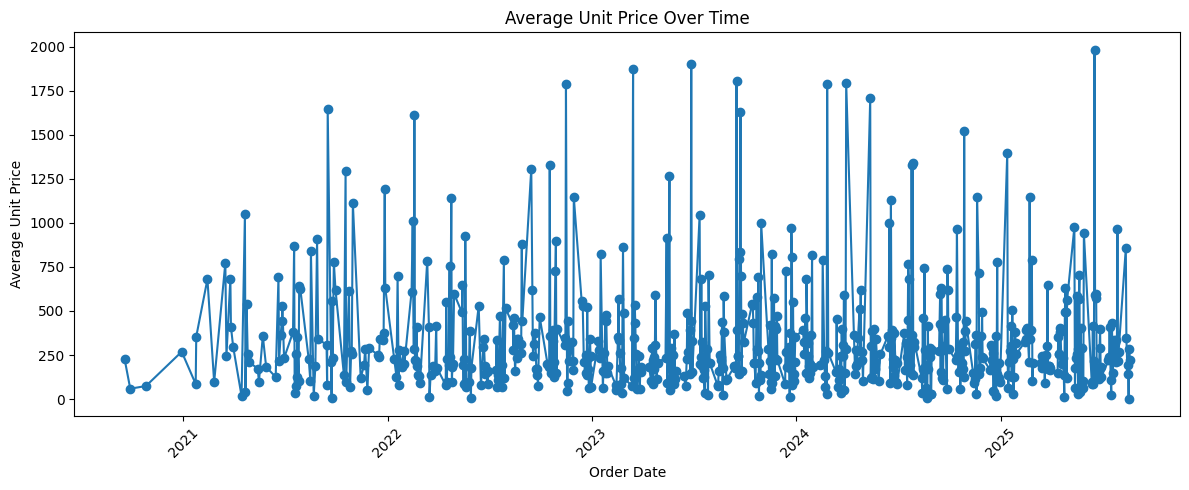

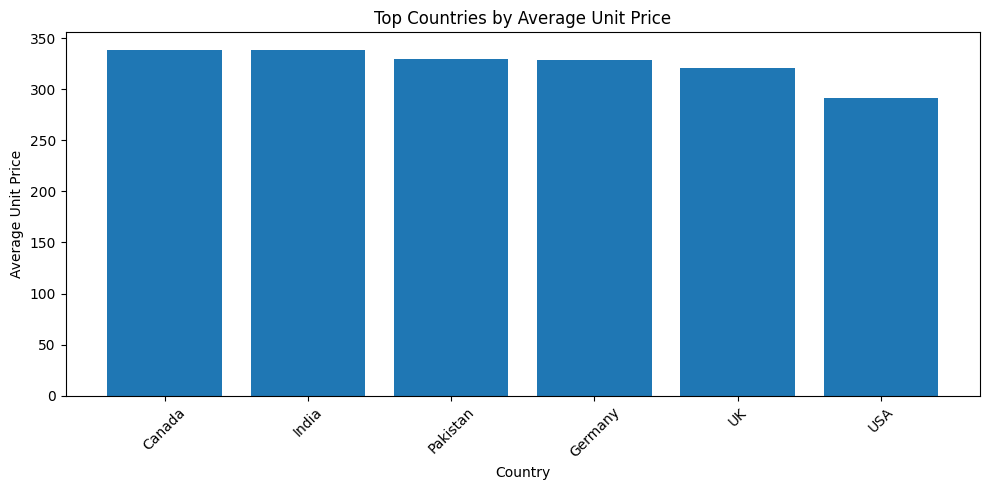

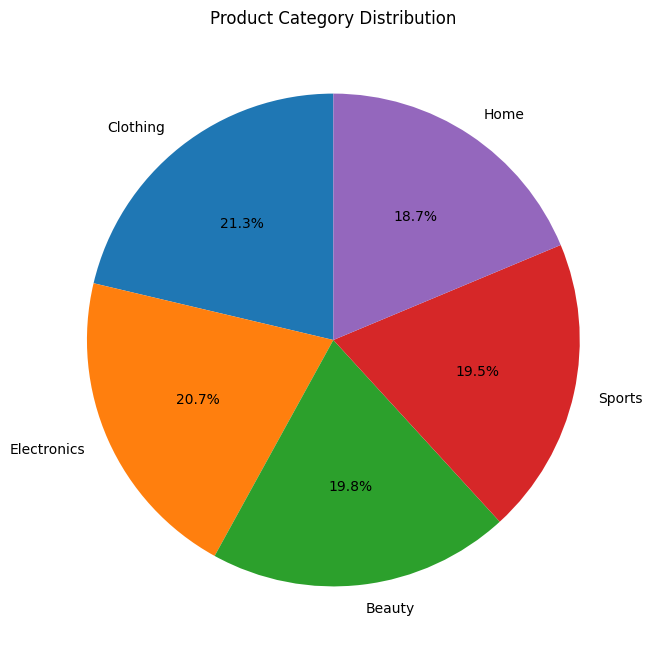

In [1]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print(df.head())

df["order_date"] = pd.to_datetime(
    df["order_date"],
    errors="coerce"
)

daily_price = (
    df.groupby("order_date")["unit_price"]
    .mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    daily_price.index,
    daily_price.values,
    marker="o"
)

plt.title("Average Unit Price Over Time")
plt.xlabel("Order Date")
plt.ylabel("Average Unit Price")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

country_avg = (
    df.groupby("country")["unit_price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.bar(
    country_avg.index,
    country_avg.values
)

plt.title("Top Countries by Average Unit Price")
plt.xlabel("Country")
plt.ylabel("Average Unit Price")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

category_count = df["category"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    category_count.values,
    labels=category_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Product Category Distribution")

plt.show()